## Modeling
In this notebook I test out different models and how they work on the dataset.

In [1]:
# Import models from script folder
import sys
import os

# Add project root to Python path
sys.path.append(os.path.abspath('..')) # This is to ensure the path gets found correctly

import script.data_preprocessing as dp
import script.data_visualization as dv
import script.data_modeling as dm

In [2]:
# load in the data
X_train, X_val, X_test, y_train, y_val, y_test = dp.load_split_data('dataset1')

In [3]:
X_train.head()

,Flow rate (Mean),TS outlet pressure (Mean),TS inlet pressure (Mean),Pump outlet pressure (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Temperature TS inlet (Mean),Bypass temperature (Mean)
0,2006.990755,0.663001,1.006496,1.122522,-6.231957,-6.344172,-6.309016,25.589479
1,2006.802163,0.666047,1.010171,1.129320,-6.287087,-6.373047,-6.327391,25.573727
2,2006.990755,0.666782,1.016682,1.137956,-6.245083,-6.338922,-6.322141,25.592105
3,2005.764905,0.662791,1.010171,1.127850,-6.255584,-6.370422,-6.324766,25.584228
4,2005.576313,0.663421,1.014057,1.130607,-6.247708,-6.375672,-6.322141,25.589479


In [4]:
y_train.head()

,Plug_future
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0


### Baseline model

In [5]:
baseline = dm.baseline_model(X_train, y_train, X_val, y_val)

Validation set results (baseline):
              precision    recall  f1-score   support

         0.0      0.968     1.000     0.984      1531
         1.0      0.000     0.000     0.000        50

    accuracy                          0.968      1581
   macro avg      0.484     0.500     0.492      1581
weighted avg      0.938     0.968     0.953      1581



/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### RandomForestClassifier

In [6]:
model = dm.train_and_evaluate_rf(X_train, X_val, y_train, y_val)

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Validation accuracy: 0.782


### Check feature importance / redundancy

/Users/karolinagil/Documents/Master/script/data_visualization.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


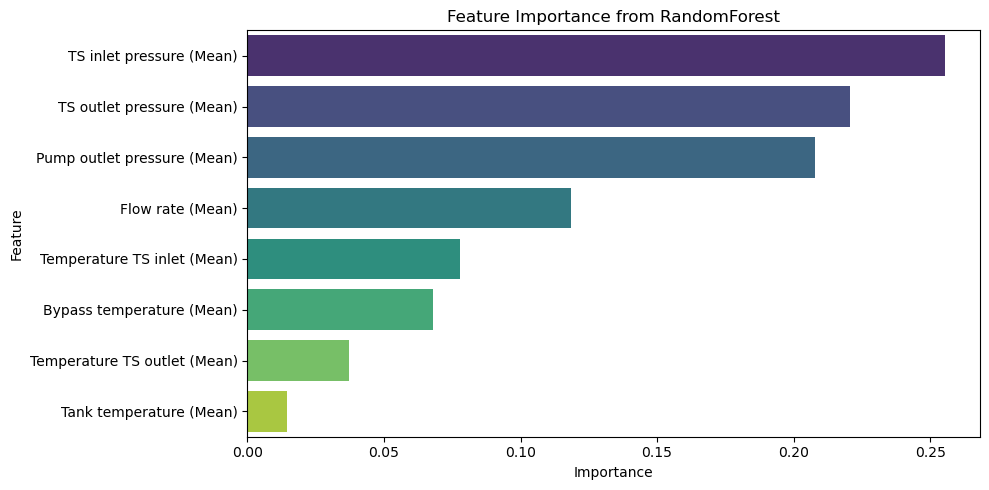

In [7]:
feat_imp = dv.plot_feature_importance(model, X_train)

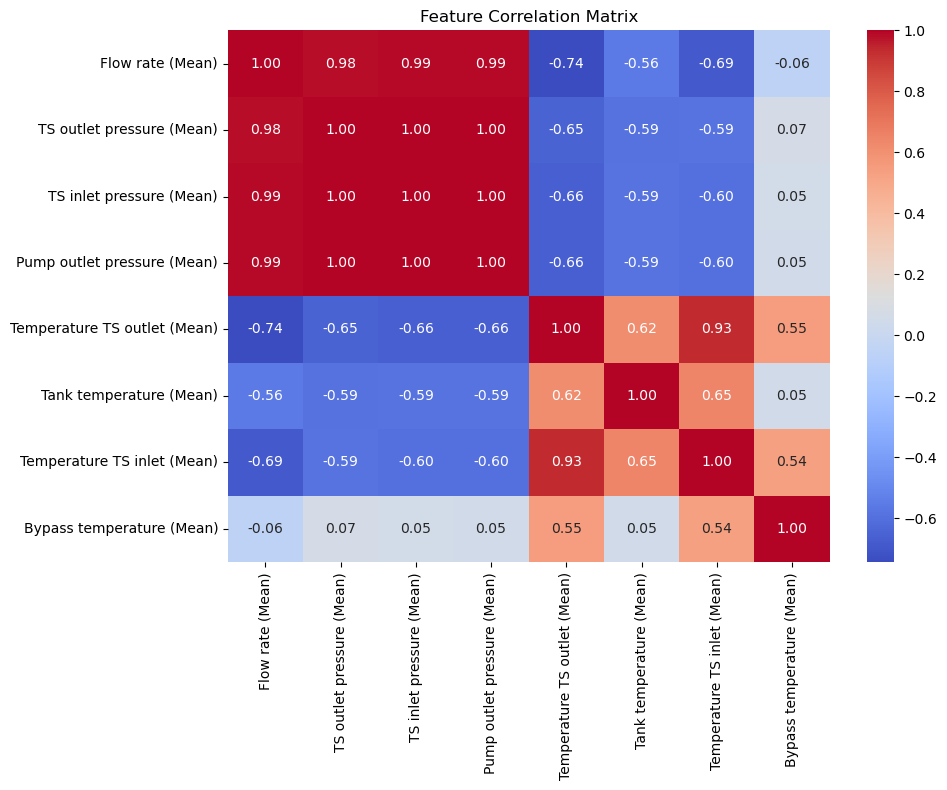

In [8]:
dv.plot_correlation_matrix(X_train)

In [9]:
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_low_importance_features(X_train, X_val, X_test, feat_imp, threshold=0.01)
X_train_reduced, X_val_reduced, X_test_reduced = dp.remove_highly_correlated_features(X_train_reduced, X_val_reduced, X_test_reduced, threshold=0.9)

In [10]:
X_train_reduced.head(5)

,Flow rate (Mean),Temperature TS outlet (Mean),Tank temperature (Mean),Bypass temperature (Mean)
0,2006.990755,-6.231957,-6.344172,25.589479
1,2006.802163,-6.287087,-6.373047,25.573727
2,2006.990755,-6.245083,-6.338922,25.592105
3,2005.764905,-6.255584,-6.370422,25.584228
4,2005.576313,-6.247708,-6.375672,25.589479


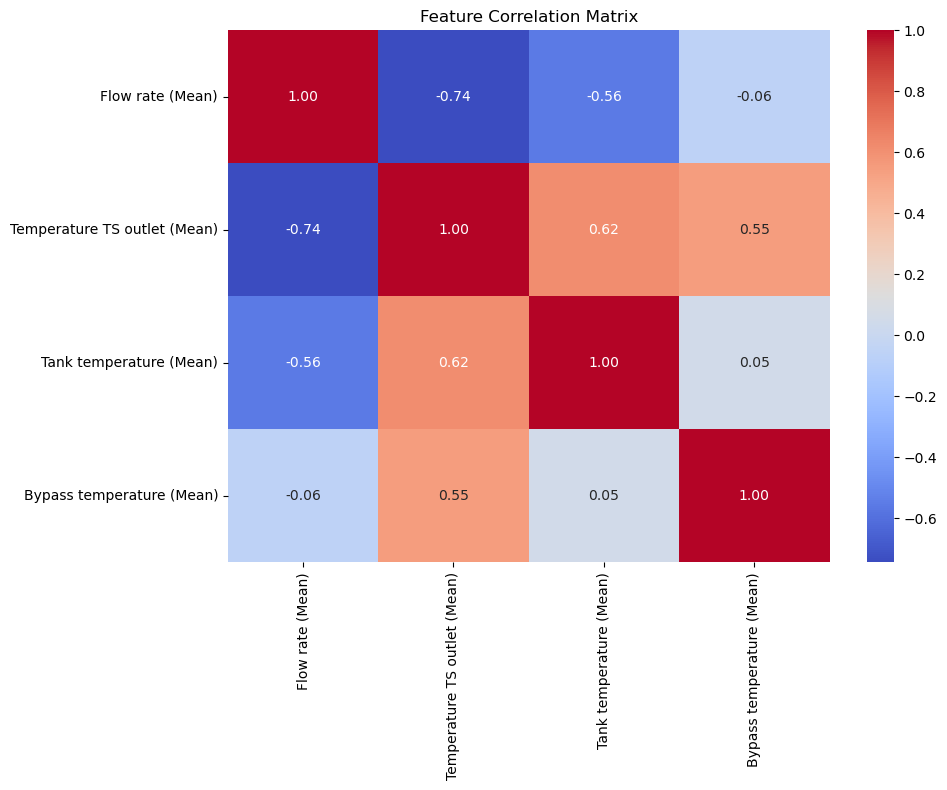

In [11]:
dv.plot_correlation_matrix(X_train_reduced)

In [12]:
model_reduced = dm.train_and_evaluate_rf(X_train_reduced, X_val_reduced, y_train, y_val)

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Validation accuracy: 0.968


/Users/karolinagil/Documents/Master/script/data_visualization.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


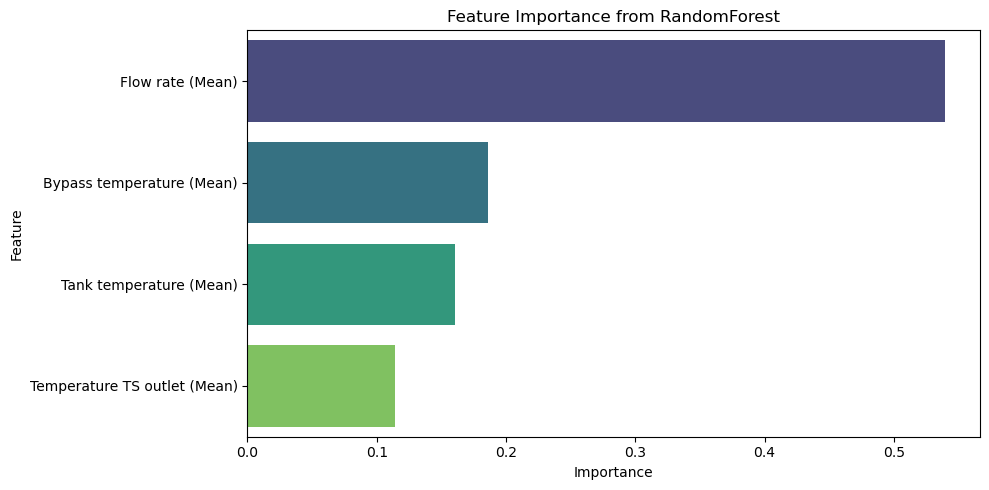

In [13]:
feat_imp_reduced = dv.plot_feature_importance(model_reduced, X_train_reduced)

### Upsampling

In [14]:
#dm.SMOTE_model(X_train_reduced, y_train, X_val_reduced, y_val)

### Downsampling

In [ ]:
#dm.undersample_model(X_train_reduced, y_train, X_val_reduced, y_val)

After undersampling: Plug_future
0.0            278
1.0            278
Name: count, dtype: int64
After undersampling (%): Plug_future
0.0            0.5
1.0            0.5
Name: proportion, dtype: float64


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Validation set results (undersample):
              precision    recall  f1-score   support

         0.0      0.991     0.905     0.946      1531
         1.0      0.207     0.760     0.325        50

    accuracy                          0.900      1581
   macro avg      0.599     0.832     0.635      1581
weighted avg      0.967     0.900     0.926      1581



RandomForestClassifier(random_state=42)

In [ ]:
# Check class balance for the target variable
print(y_train["Plug_future"].value_counts())
print(y_train["Plug_future"].value_counts(normalize=True))

KeyError: 'Plug'

### Logreg

In [17]:
X_train_scaled, X_val_scaled, X_test_scaled = dp.scale_features(X_train, X_val, X_test)

logreg = dm.logistic_regression_model(X_train_scaled, y_train, X_val_scaled, y_val)

/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Validation set results for logistic regression:
              precision    recall  f1-score   support

         0.0      1.000     0.686     0.814      1531
         1.0      0.094     1.000     0.172        50

    accuracy                          0.696      1581
   macro avg      0.547     0.843     0.493      1581
weighted avg      0.971     0.696     0.793      1581



# Finding the best model
Training and evaluating different models to find the best one.
Performing hyperparametersearch on the models to find the best hyperparameters as well.

In [18]:
best_model = dm.find_best_model(X_train, y_train, X_val, y_val)


🔍 Tuning Random Forest...
Searching over 4 hyperparameter combinations...


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: {'n_estimators': 100, 'max_depth': 10} | Validation Accuracy = 0.8488


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Params: {'n_estimators': 100, 'max_depth': 20} | Validation Accuracy = 0.8425


...

Params: {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01} | Validation Accuracy = 0.9886


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:15:14] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.1} | Validation Accuracy = 0.9905


/opt/anaconda3/envs/INF265/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [09:15:15] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_abwcuua5oq/croot/xgboost-split_1749630928197/work/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Params: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.01} | Validation Accuracy = 0.9886

✅ Best parameters found: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}
Best validation accuracy: 0.9905
Best XGBoost model with params: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1} achieved validation accuracy: 0.9905

Summary of Best Validation Accuracies:
              Model  Best Validation Accuracy
      Random Forest                  0.848830
Logistic Regression                  0.986085
                SVM                  0.968374
            XGBoost                  0.990512

🏆 Best overall model: XGBoost with validation accuracy: 0.9905
